In [18]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Input, Model, layers
from tensorflow.keras.layers import Dense, Concatenate
from tensorflow.keras.regularizers import Regularizer
from tensorflow.keras import regularizers
import scipy.stats as ss
from scipy.linalg import null_space
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [19]:
# Load the data from csv files
df = pd.read_csv("../test_files/test_4ring_var_rates/test_4ring.csv")
ka_mat = np.loadtxt("../test_files/test_4ring_var_rates/test_4ring_ka_mat.nptxt")
ka_contrib = np.loadtxt("../test_files/test_4ring_var_rates/test_4ring_rate_contrib_mat.nptxt")
x = df["seq"].values
y = df["raw_activity"].values

enc = OneHotEncoder(categories=[["A", "B"]], sparse=False)

# Encode sequences as one-hot vectors
n_samples = len(x)
seq_length = len(x[0])  # Assuming all sequences have the same length
flat = np.array([list(seq) for seq in x]).flatten()[:, None]
encoded = enc.fit_transform(flat)
x = encoded.reshape(n_samples, seq_length, 2)  # shape: (n_samples, seq_length, 2)
print(ka_mat)

[[0. 1. 0. 1. 0. 0. 1.]
 [0. 1. 0. 0. 1. 0. 1.]
 [0. 0. 1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0. 1. 0.]
 [1. 0. 0. 1. 0. 0. 1.]
 [1. 0. 0. 0. 1. 0. 1.]
 [1. 0. 0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 0. 0. 1.]
 [1. 0. 1. 0. 0. 1. 0.]
 [1. 0. 1. 0. 1. 0. 0.]]


In [20]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=777
)

In [4]:
# No regularizations
inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=32, validation_data=(x_test, y_test)
)


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
(10, 7)
(7, 10)
Train on 800 samples, validate on 200 samples
Epoch 1/500
800/800 [==============================] - 0s 238us/sample - loss: 0.0229 - val_loss: 0.0191
Epoch 2/500
 32/800 [>.............................] - ETA: 0s - loss: 0.0225

2025-07-16 22:45:08.177296: I tensorflow/core/platform/cpu_feature_guard.cc:142] Your CPU supports instructions that this TensorFlow binary was not compiled to use: AVX2 FMA


800/800 [==============================] - 0s 40us/sample - loss: 0.0196 - val_loss: 0.0163
Epoch 3/500
800/800 [==============================] - 0s 42us/sample - loss: 0.0166 - val_loss: 0.0136
Epoch 4/500
800/800 [==============================] - 0s 40us/sample - loss: 0.0137 - val_loss: 0.0113
Epoch 5/500
800/800 [==============================] - 0s 37us/sample - loss: 0.0110 - val_loss: 0.0092
Epoch 6/500
800/800 [==============================] - 0s 37us/sample - loss: 0.0087 - val_loss: 0.0074
Epoch 7/500
800/800 [==============================] - 0s 40us/sample - loss: 0.0068 - val_loss: 0.0060
Epoch 8/500
800/800 [==============================] - 0s 38us/sample - loss: 0.0052 - val_loss: 0.0047
Epoch 9/500
800/800 [==============================] - 0s 38us/sample - loss: 0.0040 - val_loss: 0.0037
Epoch 10/500
800/800 [==============================] - 0s 37us/sample - loss: 0.0030 - val_loss: 0.0029
Epoch 11/500
800/800 [==============================] - 0s 37us/sample - lo

Exp Biases: [1.2671824  1.0940131  0.9433028  1.1697682  0.99803925 1.3259028  0.8070638 ]
Weights:
 [[-0.10454012 -0.31566092 -0.1729334  -0.15460838 -0.11204176 -0.31253782  0.47514865]
 [ 0.08541876  0.22211628 -0.05101868 -0.22694448  0.27041245 -0.0711519  -0.32660356]
 [ 0.3000222  -0.44905108  0.03722796 -0.5214594  -0.23405987  0.10279594  0.32608688]
 [ 0.5297228  -0.20600055  0.3781193   0.22204399 -0.30214936  0.3052864  -0.41497695]
 [-0.06361894  0.5707678  -0.01458092 -0.47085777  0.7656114  -0.13037351 -0.10638102]
 [-0.41996667 -0.14639293  0.12931891  0.08634765  0.02428003 -0.13469408 -0.62336046]
 [ 0.13111408 -0.10264964  0.49312896 -0.13914567 -0.12456972 -0.34130695  0.39689225]
 [ 0.3562619  -0.31591564 -0.5359943   0.9926774   0.26156187  0.38540208  0.28669637]
 [ 0.55060875  0.2898035   0.7618066  -0.07363059  0.18392135  0.52939683 -0.26705554]
 [ 0.19647431 -0.30112928 -0.7810305  -0.1239477  -0.3021639   0.45704463 -0.3117296 ]
 [-0.15361914 -0.06434373 -0.

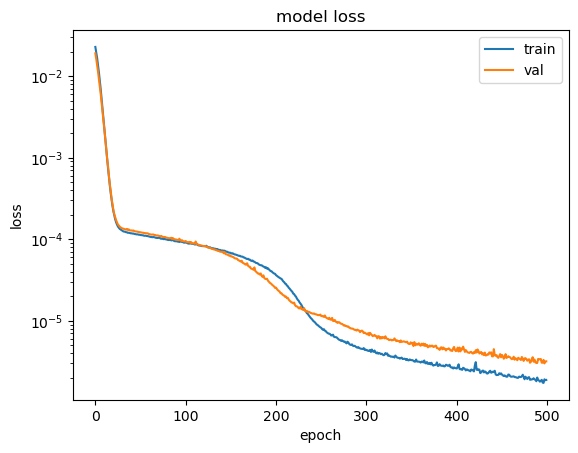

In [5]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)

In [21]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix
class LogRateRegularize(Regularizer):
    def __init__(self, coeff=1e-4):
        self.coeff = coeff

    def __call__(self, x):
        # Here x is the ACTIVATION output of the layer
        # Example: L1 norm on activations
        return self.coeff * tf.reduce_sum(tf.exp(x))

    def get_config(self):
        return {'coeff': float(self.coeff)}

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", kernel_regularizer=LogRateRegularize(1e-7))(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=1000, batch_size=16, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 800 samples, validate on 200 samples
Epoch 1/1000
800/800 [==============================] - 0s 431us/sample - loss: 0.0170 - val_loss: 0.0133
Epoch 2/1000
800/800 [==============================] - 0s 56us/sample - loss: 0.0120 - val_loss: 0.0093
Epoch 3/1000
800/800 [==============================] - 0s 183us/sample - loss: 0.0078 - val_loss: 0.0061
Epoch 4/1000
800/800 [==============================] - 0s 57us/sample - loss: 0.0048 - val_loss: 0.0038
Epoch 5/1000
800/800 [==============================] - 0s 56us/sample - loss: 0.0029 - val_loss: 0.0023
Epoch 6/1000
800/800 [==============================] - 0s 53us/sample - loss: 0.0018 - val_loss: 0.0015
Epoch 7/1000
800/800 [==============================] - 0s 59us/sample - loss: 0.0012 - val_loss: 9.2591e-04
Epoch 8/1000
800/800 [==============================] - 0s 75us/sample - loss: 7.7466e-04 - val_loss: 5.7648e-04
Epoch 9/1000
800/800 [==============================] - 0s 89us/sample - loss: 5.281

Exp Biases: [1.3310602  1.4692392  1.0197283  1.3010819  0.94432956 1.7176912  1.145957  ]
Weights:
 [[ 0.14734463  0.09370558  0.39725107 -0.09166124 -0.06404363 -0.02936252 -0.2213195 ]
 [-0.864728   -0.5383912   0.31009883 -0.42892376  0.12803663 -0.2848538  -1.1595632 ]
 [-0.06796848 -0.29705295  0.3018076   0.28983945  0.16397423  0.02683412  0.20314915]
 [-0.8286918   0.17823961 -0.0247072  -1.0062634  -0.27922362 -0.06179835 -0.9736578 ]
 [ 0.30904618 -0.5622218   0.25427008  0.46469483  0.33345437 -0.19008426 -0.06987708]
 [-0.24133708  0.18662572 -0.4650827  -1.641982   -0.7347073   0.07232292 -0.77996105]
 [-0.04355436 -0.7600989  -0.5485848  -0.01078175  0.15462549 -0.24427168  0.22582631]
 [-0.38721818  0.77084446 -0.14781873  0.09016015 -0.742152   -0.19191676 -1.110777  ]
 [ 0.10851024 -0.35948995 -0.12423236 -0.29524523  0.0902882  -0.3854508   0.32877222]
 [-0.38804108 -0.10019626 -0.27831787  0.04330156 -0.8299507  -0.53876734 -0.5714601 ]
 [-0.29286793  0.0946888  -0.

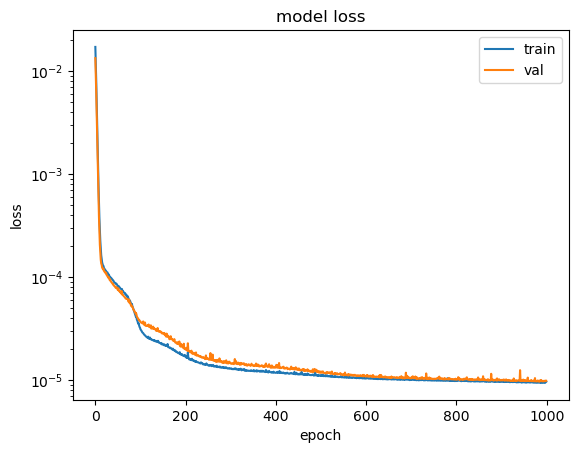

In [22]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)

In [15]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix
class LogRateL1Regularize(Regularizer):
    def __init__(self, coeff=1e-4):
        self.coeff = coeff

    def __call__(self, x):
        return self.coeff * tf.reduce_mean(tf.exp(x))

    def get_config(self):
        return {'coeff': float(self.coeff)}

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=LogRateL1Regularize(1e-6), 
    bias_regularizer=LogRateL1Regularize(1e-6), 
    # activity_regularizer=LogRateL1Regularize(1e-6), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=16, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 800 samples, validate on 200 samples
Epoch 1/500
800/800 [==============================] - 0s 291us/sample - loss: 0.0129 - val_loss: 0.0096
Epoch 2/500
800/800 [==============================] - 0s 51us/sample - loss: 0.0076 - val_loss: 0.0059
Epoch 3/500
800/800 [==============================] - 0s 47us/sample - loss: 0.0046 - val_loss: 0.0038
Epoch 4/500
800/800 [==============================] - 0s 50us/sample - loss: 0.0028 - val_loss: 0.0025
Epoch 5/500
800/800 [==============================] - 0s 49us/sample - loss: 0.0018 - val_loss: 0.0016
Epoch 6/500
800/800 [==============================] - 0s 53us/sample - loss: 0.0012 - val_loss: 0.0011
Epoch 7/500
800/800 [==============================] - 0s 52us/sample - loss: 7.7429e-04 - val_loss: 7.1625e-04
Epoch 8/500
800/800 [==============================] - 0s 49us/sample - loss: 5.1989e-04 - val_loss: 4.9037e-04
Epoch 9/500
800/800 [==============================] - 0s 49us/sample - loss: 3.5620e-04 

Exp Biases: [0.8873183 1.1182588 0.9061808 0.8979832 0.8889858 1.0303243 0.845232 ]
Weights:
 [[ 0.0729427   0.74274206 -0.00867316  0.30408037  0.52491075  0.6612111  -0.02444997]
 [-0.2837895  -0.10885307  0.19990352  0.56183815 -0.4820789  -0.30226168 -0.475603  ]
 [-0.36973014 -0.06360684 -0.14197366 -0.3515437   0.52480197  0.01553074 -0.0626897 ]
 [-0.19693467  0.3635661   0.6732938   0.1968931  -0.75074404 -0.4384774  -0.6560645 ]
 [ 0.28153035  0.08485    -0.4643793   0.31256363  0.68007743 -0.12252753  0.31546488]
 [-0.602901    0.02959486  0.13666536  0.17706017 -0.44325155 -0.01042153 -0.3397654 ]
 [-0.25869855 -0.35021883  0.4347677  -0.08841558 -0.01130677 -0.408568    0.09428165]
 [ 0.27725905  0.64696723 -0.07697944  0.7585526  -0.05626472  0.46200657  0.01592937]
 [ 0.45545074 -0.12410399  0.74489003 -0.03980594 -0.22912441 -0.402673    0.0780967 ]
 [ 0.10771871 -0.24542479 -0.60613817  0.0200939  -0.16937968 -0.12522146 -0.21184978]
 [ 0.4008326  -0.09176055  0.2110190

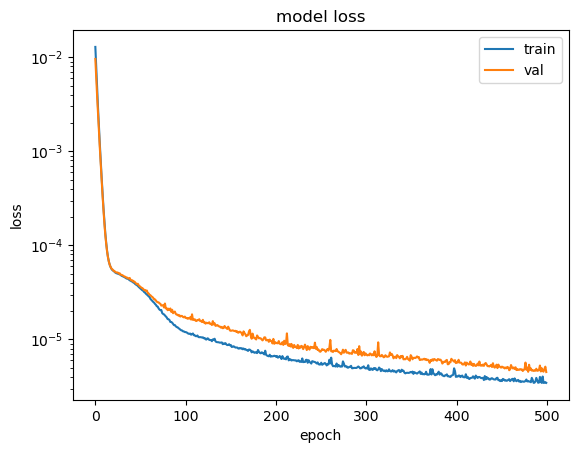

In [16]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)

In [17]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix
class LogRateL1SumRegularize(Regularizer):
    def __init__(self, coeff=1e-4):
        self.coeff = coeff

    def __call__(self, x):
        return self.coeff * tf.reduce_sum(tf.exp(x))

    def get_config(self):
        return {'coeff': float(self.coeff)}

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=LogRateL1SumRegularize(1e-6), 
    bias_regularizer=LogRateL1SumRegularize(1e-6), 
    # activity_regularizer=LogRateL1SumRegularize(1e-6), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=500, batch_size=16, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 800 samples, validate on 200 samples
Epoch 1/500
800/800 [==============================] - 0s 395us/sample - loss: 0.0254 - val_loss: 0.0208
Epoch 2/500
800/800 [==============================] - 0s 53us/sample - loss: 0.0167 - val_loss: 0.0083
Epoch 3/500
800/800 [==============================] - 0s 49us/sample - loss: 0.0048 - val_loss: 0.0022
Epoch 4/500
800/800 [==============================] - 0s 49us/sample - loss: 0.0016 - val_loss: 9.1517e-04
Epoch 5/500
800/800 [==============================] - 0s 47us/sample - loss: 7.8549e-04 - val_loss: 5.2432e-04
Epoch 6/500
800/800 [==============================] - 0s 48us/sample - loss: 5.0138e-04 - val_loss: 3.7024e-04
Epoch 7/500
800/800 [==============================] - 0s 51us/sample - loss: 3.7532e-04 - val_loss: 3.0351e-04
Epoch 8/500
800/800 [==============================] - 0s 50us/sample - loss: 3.1347e-04 - val_loss: 2.7276e-04
Epoch 9/500
800/800 [==============================] - 0s 51us/sample

Exp Biases: [1.3457986  0.26341385 1.2625647  0.19077665 1.2467107  0.2288395  1.0540972 ]
Exp Weights:
 [[1.0073411  0.17605369 1.1191877  0.15335153 1.219197   0.21918851 1.0956984 ]
 [0.8516606  0.1653071  0.8826119  0.10074285 0.5543749  0.1153294  0.78491384]
 [0.95273733 0.21655582 1.0188079  0.13092607 1.295483   0.18077283 0.68569523]
 [0.53389114 0.1142435  0.4120316  0.12259852 0.28839174 0.10713653 0.683088  ]
 [0.8810196  0.21317643 1.0348343  0.10747849 1.1481923  0.13929932 1.3996994 ]
 [0.49097696 0.11224487 0.27995634 0.15246698 0.2683157  0.20785025 0.87175876]
 [1.0863723  0.24405114 1.2398015  0.09114623 1.2690918  0.23656636 0.5870781 ]
 [0.31367582 0.06856913 0.1219153  0.1684225  0.43116078 0.05541378 0.68095785]
 [1.3013294  0.2492734  1.7681024  0.1678633  0.8529344  0.24345158 0.7655074 ]
 [0.38019976 0.06515894 0.19574775 0.07578953 0.5763435  0.03204582 0.45134163]
 [1.5087428  0.05693346 1.1509116  0.15561017 0.8665362  0.23574595 0.9592819 ]
 [0.15619844 0.

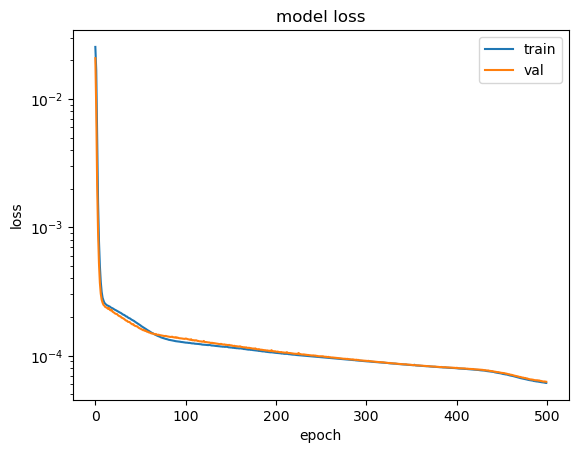

In [18]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Exp Weights:\n", np.exp(weights))
results = np.matmul(test_arr, weights) + biases
x = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)

In [77]:
# Regularize based on the rates with L1 norm on the exponent of the rate matrix

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=regularizers.l1(1e-6), 
    # activity_regularizer=LogRateL1SumRegularize(1e-6), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)
print(ka_mat.shape)
print(ka_contrib.shape)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=10, batch_size=1, validation_data=(x_test, y_test)
)


(10, 7)
(7, 10)
Train on 1600 samples, validate on 400 samples
Epoch 1/10
1600/1600 [==============================] - 2s 1ms/sample - loss: 5.2815e-04 - val_loss: 3.7428e-05
Epoch 2/10
1600/1600 [==============================] - 1s 803us/sample - loss: 2.9254e-05 - val_loss: 2.6757e-05
Epoch 3/10
1600/1600 [==============================] - 1s 837us/sample - loss: 2.6527e-05 - val_loss: 2.5510e-05
Epoch 4/10
1600/1600 [==============================] - 1s 796us/sample - loss: 2.5386e-05 - val_loss: 2.4555e-05
Epoch 5/10
1600/1600 [==============================] - 1s 801us/sample - loss: 2.3941e-05 - val_loss: 2.2616e-05
Epoch 6/10
1600/1600 [==============================] - 1s 809us/sample - loss: 2.1863e-05 - val_loss: 2.3866e-05
Epoch 7/10
1600/1600 [==============================] - 1s 775us/sample - loss: 1.9937e-05 - val_loss: 1.7724e-05
Epoch 8/10
1600/1600 [==============================] - 1s 780us/sample - loss: 1.7930e-05 - val_loss: 1.6144e-05
Epoch 9/10
1600/1600 [=====

Exp Biases: [0.8541684  1.2821438  0.87889165 1.193442   0.8649368  1.186775   0.8871876 ]
Weights:
 [[-3.04377675e-01 -1.12100528e-03  1.55705735e-01  3.41659546e-01  2.49275833e-01  4.45667863e-01  5.16729488e-04]
 [-8.25611353e-02  3.99553716e-01 -4.32514459e-01 -1.45882237e-04 -6.17445782e-02  8.61855894e-02  2.55311048e-03]
 [ 1.87043205e-01 -3.51534247e-01  3.22017670e-01 -1.13365741e-03 -2.93253899e-01  9.14475229e-03  2.65836832e-03]
 [-2.10972607e-01  1.32123493e-02 -5.27938940e-02  5.42730272e-01 -3.22611094e-03 -1.90381089e-03  1.40654563e-03]
 [ 1.35442764e-01 -1.03187142e-03 -2.02225521e-01 -5.60296476e-02  1.82546258e-01  4.86402549e-02  4.75687295e-04]
 [-3.51276815e-01  2.13153303e-01 -2.91729253e-02  1.06410362e-01 -2.91433819e-02 -1.06614409e-03  4.94948763e-04]
 [ 3.64539842e-03 -2.26651937e-01  2.13843718e-01  1.51386529e-01  5.12371004e-01  1.45516515e-01 -1.58006489e-01]
 [-1.12265619e-02  1.91075474e-01 -3.18523087e-02  8.35065320e-02 -3.39648843e-01  2.47725233e

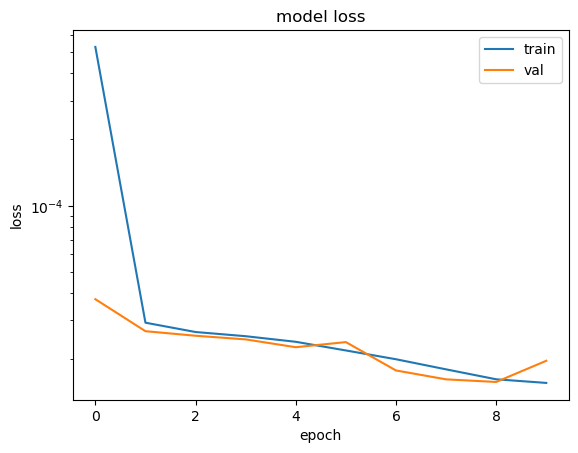

In [78]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights.T, axis=1))
# print("Exp Weights:\n", np.exp(weights))
results = np.matmul(test_arr, weights) + biases
x = np.array([[1, 0]] * 7).reshape(1, 7, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)

In [16]:
# Regularize based on entropy of the rate matrix
class ColumnEntropyRegularizer(Regularizer):
    def __init__(self, coeff=1e-3):
        self.coeff = coeff
    def __call__(self, W):
        P = tf.nn.softmax(W, axis=1)  # normalize rows
        entropy = -tf.reduce_sum(P * tf.math.log(P + 1e-8), axis=1)
        return self.coeff * tf.reduce_mean(entropy)

inputs = layers.Input(shape=(seq_length, 2))  # one-hot encoded 'A'/'B' per position
flat = layers.Flatten()(inputs)  # flatten the input
log_rates = layers.Dense(
    7, activation="linear", name="log_rates", 
    kernel_regularizer=ColumnEntropyRegularizer(1e-5), 
    )(flat)  # hidden layer
KA_terms = layers.Lambda(
    lambda x: tf.nn.softmax(
        tf.matmul(x, tf.constant(ka_mat, dtype=tf.float32), transpose_b=True)
    ),
    name="KA_terms",
)(log_rates)

# Corrected Lambda for contrib_KA_terms
contrib_KA_terms = layers.Lambda(
    lambda x: tf.matmul(x, tf.constant(ka_contrib, dtype=tf.float32), transpose_b=True),
    name="contrib_KA_terms",
)(KA_terms)
exp_rates = layers.Lambda(lambda x: tf.exp(x), name="exp_log_rates")(log_rates)
output = layers.Dot(axes=1, name="dot_output")([contrib_KA_terms, exp_rates])
model = Model(inputs=inputs, outputs=output)


model.compile(optimizer="adam", loss="mse")

# Train the model
hist = model.fit(
    x_train, y_train, epochs=1000, batch_size=16, validation_data=(x_test, y_test)
)


Train on 800 samples, validate on 200 samples
Epoch 1/1000
800/800 [==============================] - 0s 543us/sample - loss: 0.0234 - val_loss: 0.0188
Epoch 2/1000
800/800 [==============================] - 0s 74us/sample - loss: 0.0178 - val_loss: 0.0124
Epoch 3/1000
800/800 [==============================] - 0s 71us/sample - loss: 0.0101 - val_loss: 0.0063
Epoch 4/1000
800/800 [==============================] - 0s 71us/sample - loss: 0.0045 - val_loss: 0.0030
Epoch 5/1000
800/800 [==============================] - 0s 70us/sample - loss: 0.0021 - val_loss: 0.0013
Epoch 6/1000
800/800 [==============================] - 0s 70us/sample - loss: 0.0010 - val_loss: 6.6329e-04
Epoch 7/1000
800/800 [==============================] - 0s 71us/sample - loss: 5.6048e-04 - val_loss: 3.6803e-04
Epoch 8/1000
800/800 [==============================] - 0s 76us/sample - loss: 3.5127e-04 - val_loss: 2.2621e-04
Epoch 9/1000
800/800 [==============================] - 0s 106us/sample - loss: 2.4635e-04 - 

Exp Biases: [1.3012819  0.8065922  1.2214212  1.0706385  0.926939   1.2815183  0.93189704]
Weights:
 [[-0.0845812  -0.07767997 -0.0097422   0.13979907 -0.12816474 -0.0033754   0.74908036]
 [-0.9135152  -0.19456051  0.09215876 -0.04433048  0.4147357  -0.2315329  -0.6018806 ]
 [ 0.29023388  0.5783318   0.11986806 -0.19779468  0.1406975  -0.10501807  0.17161362]
 [-0.53823054  0.5658995   0.53940773 -0.31522524 -0.22030616  0.55216956 -0.261765  ]
 [ 0.16297835 -0.85364383  0.4456619  -0.29680938 -0.15096512  0.48078564 -0.5521372 ]
 [-0.6414571  -1.0619761   0.7677691  -0.6068716  -1.1473777   1.9249895   0.1111941 ]
 [-0.3238244  -0.07458036 -0.2578006   0.2878166   0.10585895  0.0780798   0.506038  ]
 [ 0.62101984  1.2539967  -0.17649963  1.0113693  -0.22217649  0.5297249  -0.33957374]
 [-0.23908049 -0.12083202  0.05686036  0.5650626   0.06478014 -0.23479621  0.01209385]
 [-0.39831623 -0.70367897 -0.77200073  1.3924884   0.18708213  0.04912483 -0.53897226]
 [ 0.32369635 -0.50994915 -0.

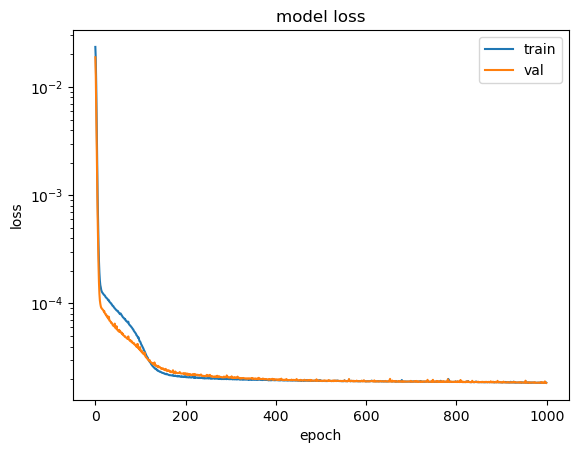

In [17]:
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"])
plt.yscale("log")
np.set_printoptions(linewidth=np.inf)
layer = model.get_layer("log_rates")  # or model.layers[0]
weights, biases = layer.get_weights()

print("Exp Biases:", np.exp(biases))
weights = np.array(weights)
print("Weights:\n", weights)
print("Max weights:", np.max(weights, axis=1))
# print("Exp Weights:\n", np.exp(weights))
x = np.array([[1, 0]] * seq_length).reshape(1, seq_length, 2)  # Template input
activation = Model(inputs=model.input, outputs=model.get_layer("log_rates").output)
activation_output = activation.predict(x)
print("Matching Rates:", np.exp(activation_output))
y = model.predict(x)
print("Activity:", y)
xoff = x.copy()
xoff[:,0]=np.array([0,1])
print("Missmatching Rates:", np.exp(activation.predict(xoff)))
print("Missmatch activity:", model.predict(xoff))

In [ ]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Fri Jul 04 2025

Python implementation: CPython
Python version       : 3.7.3
IPython version      : 7.33.0

numpy     : 1.18.5
scipy     : 1.5.3
matplotlib: 3.5.1
pandas    : 1.3.5
sklearn   : 1.0.2
tensorflow: 1.14.0
seaborn   : 0.12.2

Watermark: 2.5.0

